# Experiment: Effect of Perception Radius on Boid Swarming

The alignment experiment showed how force weights control flock coherence. Here we fix all three weights
(cohesion, separation, alignment) and instead vary the **outer (perception) radius**, the distance within
which each boid detects neighbours for alignment and cohesion.

**Rationale:** The perception radius determines *how many* neighbours a boid interacts with, rather than
*how strongly* it responds to them. A small radius confines interactions to the immediate vicinity (local
coordination), while a large radius lets each boid sense agents across the arena (global coordination).
Biologically, this corresponds to an animal's sensory range (e.g. visual distance in bird flocks or
lateral-line range in fish schools).

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import subprocess
from pathlib import Path


def velocity(df):
    df = df.sort_values(by=['id', 'time'])
    df['dx'] = df.groupby('id')['x'].diff()
    df['dy'] = df.groupby('id')['y'].diff()
    df['dt'] = df.groupby('id')['time'].diff()
    df['speed'] = np.sqrt(df['dx']**2 + df['dy']**2) / df['dt']
    return df.fillna(0)

def order_parameter(df):
    valid_df = df[df['speed'] > 0].copy()
    valid_df['ux'] = valid_df['dx'] / valid_df['speed']
    valid_df['uy'] = valid_df['dy'] / valid_df['speed']
    def compute_group_order(group):
        n_b = len(group)
        if n_b == 0: return 0
        sum_ux = group['ux'].sum()
        sum_uy = group['uy'].sum()
        total_magnitude = np.sqrt(sum_ux**2 + sum_uy**2)
        return total_magnitude / n_b
    order_series = valid_df.groupby('time').apply(compute_group_order)
    return order_series.reset_index(name='order_parameter')

def nearest_neighbor_distances(df, W=400, H=400):
    records = []
    for t, group in df.groupby('time'):
        pos = group[['x', 'y']].values
        n = len(pos)
        min_dists = np.empty(n)
        for i in range(n):
            dx = np.abs(pos[i, 0] - pos[:, 0])
            dy = np.abs(pos[i, 1] - pos[:, 1])
            dx = np.minimum(dx, W - dx)
            dy = np.minimum(dy, H - dy)
            d = np.sqrt(dx**2 + dy**2)
            d[i] = np.inf  # exclude self
            min_dists[i] = d.min()
        records.append({'time': t, 'mean_nnd': min_dists.mean(), 'median_nnd': np.median(min_dists)})
    return pd.DataFrame(records)

## Run simulations

In [26]:
# Experiment parameters
OUTER_RADII = [10, 20, 30, 40, 50, 75, 100]
N_REPLICATES = 5
FIELD = 400
N_BOIDS = 80
INNER_R = 40
COHESION = 0.2
SEPARATION = 0.2
ALIGNMENT = 0.2
T_STEPS = 301

project_root = Path('..').resolve()
analysis_dir = Path('.').resolve()
img_base = project_root / 'output-img'

for radius in OUTER_RADII:
    for run in range(1, N_REPLICATES + 1):
        csv_name = f'output-csv/output_radius_{radius}_run{run}.csv'
        csv_path = analysis_dir / csv_name

        # Skip if already generated
        if csv_path.exists():
            print(f'  Skipping radius={radius}, run {run}/{N_REPLICATES} (already exists)')
            continue

        print(f'Running radius={radius}, replicate {run}/{N_REPLICATES}...')

        cmd = (
            f'node node-boids-template.js'
            f' -f {FIELD} -N {N_BOIDS} -i {INNER_R} -o {radius}'
            f' -c {COHESION} -s {SEPARATION} -a {ALIGNMENT} -T {T_STEPS}'
        )

        # Save images only for run 1
        if run == 1:
            img_dir = img_base / f'radius_{radius}'
            cmd += f' -I "{img_dir}"'

        # Use cmd /c to avoid PowerShell UTF-16 encoding
        full_cmd = f'cmd /c "{cmd} > \"{csv_path}\""'
        subprocess.run(full_cmd, cwd=str(project_root), shell=True, check=True)

print('All simulations complete.')

  Skipping radius=10, run 1/5 (already exists)
  Skipping radius=10, run 2/5 (already exists)
  Skipping radius=10, run 3/5 (already exists)
  Skipping radius=10, run 4/5 (already exists)
  Skipping radius=10, run 5/5 (already exists)
  Skipping radius=20, run 1/5 (already exists)
  Skipping radius=20, run 2/5 (already exists)
  Skipping radius=20, run 3/5 (already exists)
  Skipping radius=20, run 4/5 (already exists)
  Skipping radius=20, run 5/5 (already exists)
Running radius=30, replicate 1/5...
Running radius=30, replicate 2/5...
Running radius=30, replicate 3/5...
Running radius=30, replicate 4/5...
Running radius=30, replicate 5/5...
  Skipping radius=40, run 1/5 (already exists)
  Skipping radius=40, run 2/5 (already exists)
  Skipping radius=40, run 3/5 (already exists)
  Skipping radius=40, run 4/5 (already exists)
  Skipping radius=40, run 5/5 (already exists)
  Skipping radius=50, run 1/5 (already exists)
  Skipping radius=50, run 2/5 (already exists)
  Skipping radius=50,

## Load results and compute metrics

In [27]:
# Load all CSVs and compute metrics
all_order = []   # list of (radius, run, order_df)
all_nnd = []     # list of (radius, run, nnd_df)
all_data = {}    # (radius, run) -> raw df

for radius in OUTER_RADII:
    for run in range(1, N_REPLICATES + 1):
        csv_path = analysis_dir / f'output-csv/output_radius_{radius}_run{run}.csv'
        df = pd.read_csv(csv_path)
        all_data[(radius, run)] = df

        vdf = velocity(df.copy())
        odf = order_parameter(vdf)
        odf['radius'] = radius
        odf['run'] = run
        all_order.append(odf)

        ndf = nearest_neighbor_distances(df, W=FIELD, H=FIELD)
        ndf['radius'] = radius
        ndf['run'] = run
        all_nnd.append(ndf)

order_all = pd.concat(all_order, ignore_index=True)
nnd_all = pd.concat(all_nnd, ignore_index=True)

print(f'Loaded {len(all_data)} runs. Order rows: {len(order_all)}, NND rows: {len(nnd_all)}')

Loaded 35 runs. Order rows: 10535, NND rows: 10570


## Plot 1: Order parameter over time (mean +/- std per perception radius)

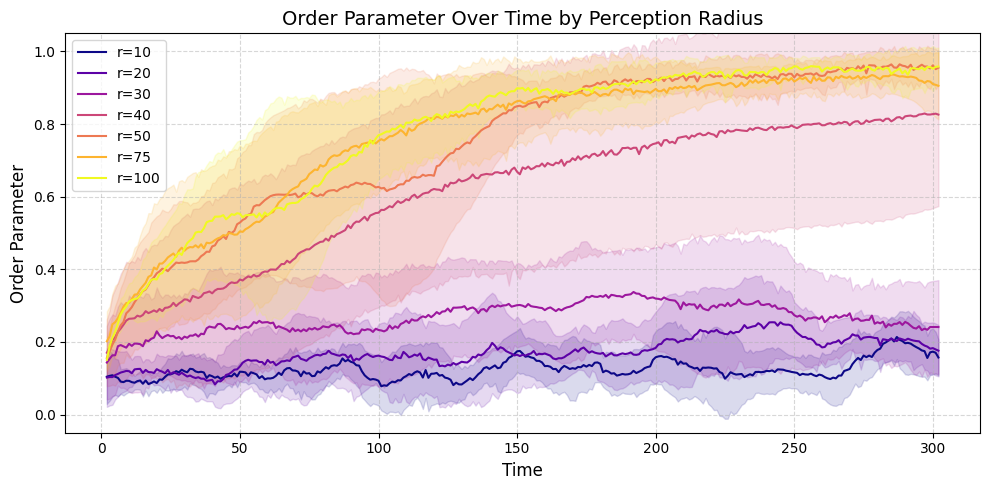

In [28]:
cmap = plt.cm.plasma
colors = {r: cmap(i / (len(OUTER_RADII) - 1)) for i, r in enumerate(OUTER_RADII)}

fig, ax = plt.subplots(figsize=(10, 5))

for r in OUTER_RADII:
    subset = order_all[order_all['radius'] == r]
    grouped = subset.groupby('time')['order_parameter']
    mean = grouped.mean()
    std = grouped.std().fillna(0)

    ax.plot(mean.index, mean.values, color=colors[r], label=f'r={r}', linewidth=1.5)
    ax.fill_between(mean.index, (mean - std).values, (mean + std).values,
                    color=colors[r], alpha=0.15)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Order Parameter', fontsize=12)
ax.set_title('Order Parameter Over Time by Perception Radius', fontsize=14)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Plot 2: Final order parameter vs perception radius (boxplot)

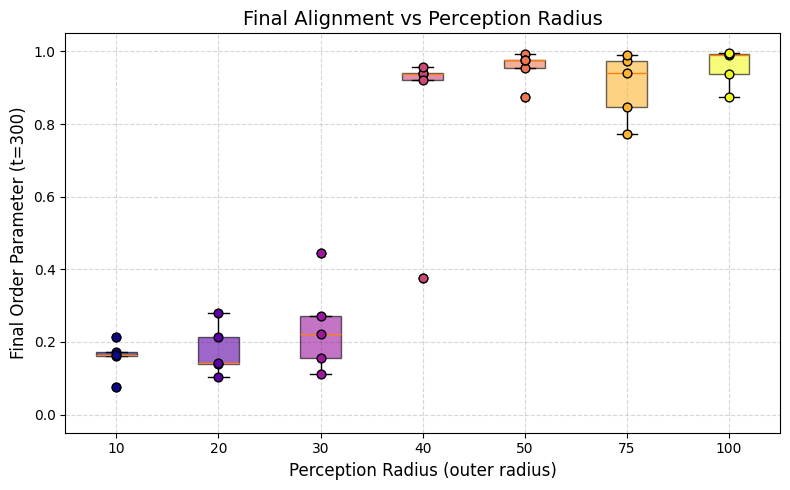

In [29]:
# Get final order parameter per run
final_order = order_all.groupby(['radius', 'run']).apply(
    lambda g: g.loc[g['time'].idxmax(), 'order_parameter']
).reset_index(name='final_order')

fig, ax = plt.subplots(figsize=(8, 5))

box_data = [final_order[final_order['radius'] == r]['final_order'].values for r in OUTER_RADII]
bp = ax.boxplot(box_data, positions=range(len(OUTER_RADII)), widths=0.4, patch_artist=True)

for i, (patch, r) in enumerate(zip(bp['boxes'], OUTER_RADII)):
    patch.set_facecolor(colors[r])
    patch.set_alpha(0.6)

# Overlay individual points
for i, r in enumerate(OUTER_RADII):
    vals = final_order[final_order['radius'] == r]['final_order'].values
    ax.scatter([i]*len(vals), vals, color=colors[r], edgecolor='black', s=40, zorder=3)

ax.set_xticks(range(len(OUTER_RADII)))
ax.set_xticklabels([str(r) for r in OUTER_RADII])
ax.set_xlabel('Perception Radius (outer radius)', fontsize=12)
ax.set_ylabel('Final Order Parameter (t=300)', fontsize=12)
ax.set_title('Final Alignment vs Perception Radius', fontsize=14)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Plot 3: Mean NND over time (mean +/- std per perception radius)

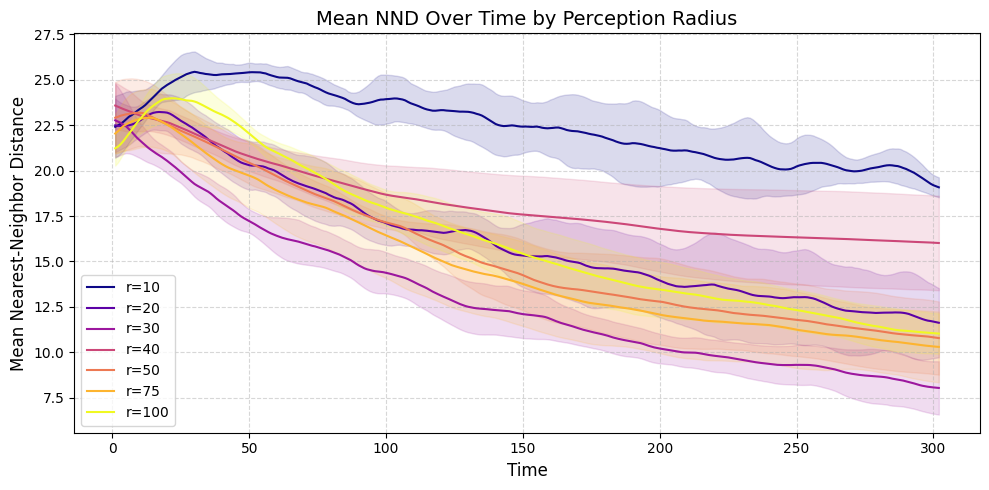

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

for r in OUTER_RADII:
    subset = nnd_all[nnd_all['radius'] == r]
    grouped = subset.groupby('time')['mean_nnd']
    mean = grouped.mean()
    std = grouped.std().fillna(0)

    ax.plot(mean.index, mean.values, color=colors[r], label=f'r={r}', linewidth=1.5)
    ax.fill_between(mean.index, (mean - std).values, (mean + std).values,
                    color=colors[r], alpha=0.15)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Mean Nearest-Neighbor Distance', fontsize=12)
ax.set_title('Mean NND Over Time by Perception Radius', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Plot 4: NND distribution at final timestep per perception radius

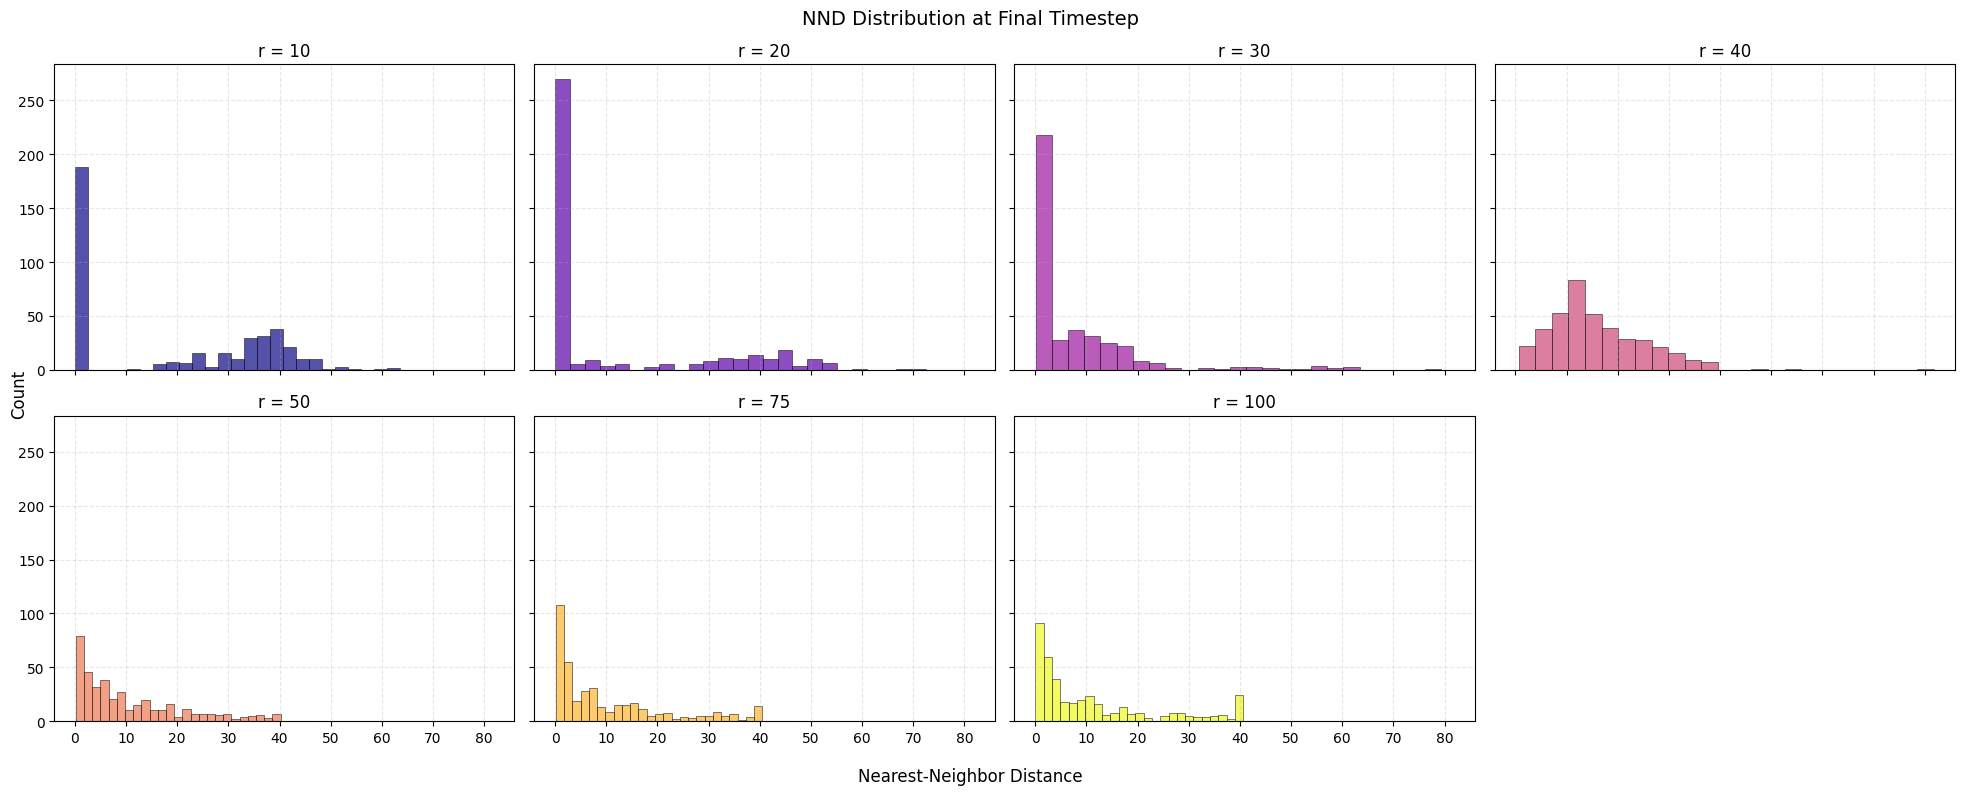

In [31]:
ncols = 4
nrows = int(np.ceil(len(OUTER_RADII) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for idx, r in enumerate(OUTER_RADII):
    ax = axes[idx // ncols, idx % ncols]

    # Compute per-boid NND at the final timestep across all runs
    all_min_dists = []
    for run in range(1, N_REPLICATES + 1):
        df = all_data[(r, run)]
        t_final = df['time'].max()
        pos = df[df['time'] == t_final][['x', 'y']].values
        n = len(pos)
        for i in range(n):
            dx = np.abs(pos[i, 0] - pos[:, 0])
            dy = np.abs(pos[i, 1] - pos[:, 1])
            dx = np.minimum(dx, FIELD - dx)
            dy = np.minimum(dy, FIELD - dy)
            d = np.sqrt(dx**2 + dy**2)
            d[i] = np.inf
            all_min_dists.append(d.min())

    ax.hist(all_min_dists, bins=25, color=colors[r], alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(f'r = {r}', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)

# Hide unused subplots
for idx in range(len(OUTER_RADII), nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

fig.supxlabel('Nearest-Neighbor Distance', fontsize=12)
fig.supylabel('Count', fontsize=12)
fig.suptitle('NND Distribution at Final Timestep', fontsize=14)
plt.tight_layout()
plt.show()

## Plot 5: Heading angle distribution at final timestep per perception radius

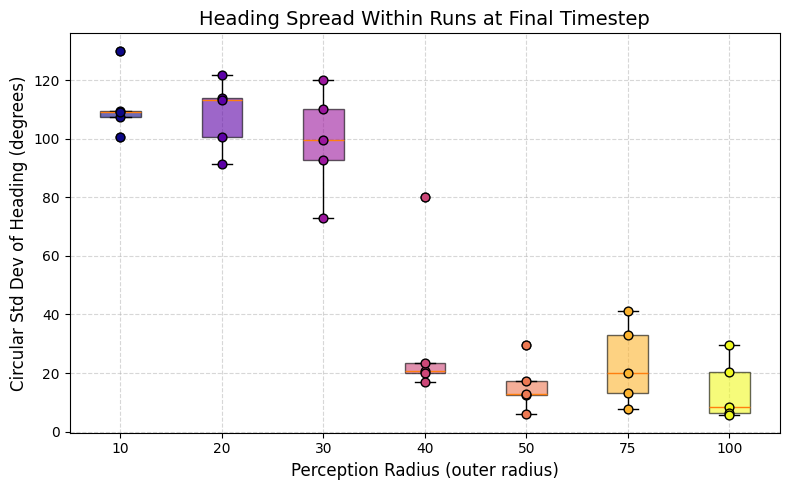

In [32]:
# Circular standard deviation per run at the final timestep
circ_std_records = []

for r in OUTER_RADII:
    for run in range(1, N_REPLICATES + 1):
        df = all_data[(r, run)]
        vdf = velocity(df.copy())
        vdf = vdf[vdf['speed'] > 0]
        t_final = vdf['time'].max()
        final = vdf[vdf['time'] == t_final]

        # Heading angles in radians
        theta = np.arctan2(final['dy'].values, final['dx'].values)
        n = len(theta)

        # Mean resultant length R
        R = np.sqrt(np.sum(np.cos(theta))**2 + np.sum(np.sin(theta))**2) / n

        # Circular std dev (in degrees); clamp R to avoid log(0)
        R_clamped = min(R, 1.0 - 1e-10)
        circ_std_deg = np.degrees(np.sqrt(-2 * np.log(R_clamped)))

        circ_std_records.append({'radius': r, 'run': run, 'circ_std': circ_std_deg})

circ_std_df = pd.DataFrame(circ_std_records)

# Boxplot
fig, ax = plt.subplots(figsize=(8, 5))

box_data = [circ_std_df[circ_std_df['radius'] == r]['circ_std'].values for r in OUTER_RADII]
bp = ax.boxplot(box_data, positions=range(len(OUTER_RADII)), widths=0.4, patch_artist=True)

for i, (patch, r) in enumerate(zip(bp['boxes'], OUTER_RADII)):
    patch.set_facecolor(colors[r])
    patch.set_alpha(0.6)

# Overlay individual points
for i, r in enumerate(OUTER_RADII):
    vals = circ_std_df[circ_std_df['radius'] == r]['circ_std'].values
    ax.scatter([i]*len(vals), vals, color=colors[r], edgecolor='black', s=40, zorder=3)

ax.set_xticks(range(len(OUTER_RADII)))
ax.set_xticklabels([str(r) for r in OUTER_RADII])
ax.set_xlabel('Perception Radius (outer radius)', fontsize=12)
ax.set_ylabel('Circular Std Dev of Heading (degrees)', fontsize=12)
ax.set_title('Heading Spread Within Runs at Final Timestep', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Observations

TODO: Observations — describe how perception radius affects order parameter convergence speed, final alignment, and nearest-neighbor spacing.